# **FORCASTING USING MULTIPLE MODELS**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [4]:
# --- 1. Load and Split Data ---
dataset = sm.datasets.get_rdataset("AirPassengers")
df = dataset.data
df['time'] = pd.date_range(start='1949-01-01', periods=len(df), freq='MS')
df.set_index('time', inplace=True)
data = df['value']

In [5]:
# Split: Train (All except last 12 months) vs Test (Last 12 months)
train = data.iloc[:-12]
test = data.iloc[-12:]

In [6]:
# --- 2. Fit Models ---

# (a) Simple Exponential Smoothing (SES)
# Assumes no trend, no seasonality
model_ses = SimpleExpSmoothing(train).fit()
pred_ses = model_ses.forecast(12)

/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [7]:
# (b) Holt’s Linear Trend Method
# Assumes Trend, but no Seasonality
model_holt = Holt(train).fit()
pred_holt = model_holt.forecast(12)

/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [8]:
# (c) Holt-Winters Method (Triple Smoothing)
# Assumes Trend + Seasonality (Multiplicative is best for this data)
model_hw = ExponentialSmoothing(train, 
                                trend='add', 
                                seasonal='mul', 
                                seasonal_periods=12).fit()
pred_hw = model_hw.forecast(12)

/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
# (d) ARIMA (Standard)
# We use (2,1,2) as a generic non-seasonal ARIMA fit
model_arima = ARIMA(train, order=(2, 1, 2)).fit()
pred_arima = model_arima.forecast(12)

/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
# --- 3. Evaluation Metrics (RMSE & MAPE) ---
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'Model': model_name, 'RMSE': rmse, 'MAPE (%)': mape}
results = []
results.append(evaluate(test, pred_ses, "SES"))
results.append(evaluate(test, pred_holt, "Holt's Linear"))
results.append(evaluate(test, pred_hw, "Holt-Winters"))
results.append(evaluate(test, pred_arima, "ARIMA(2,1,2)"))

results_df = pd.DataFrame(results).set_index('Model')

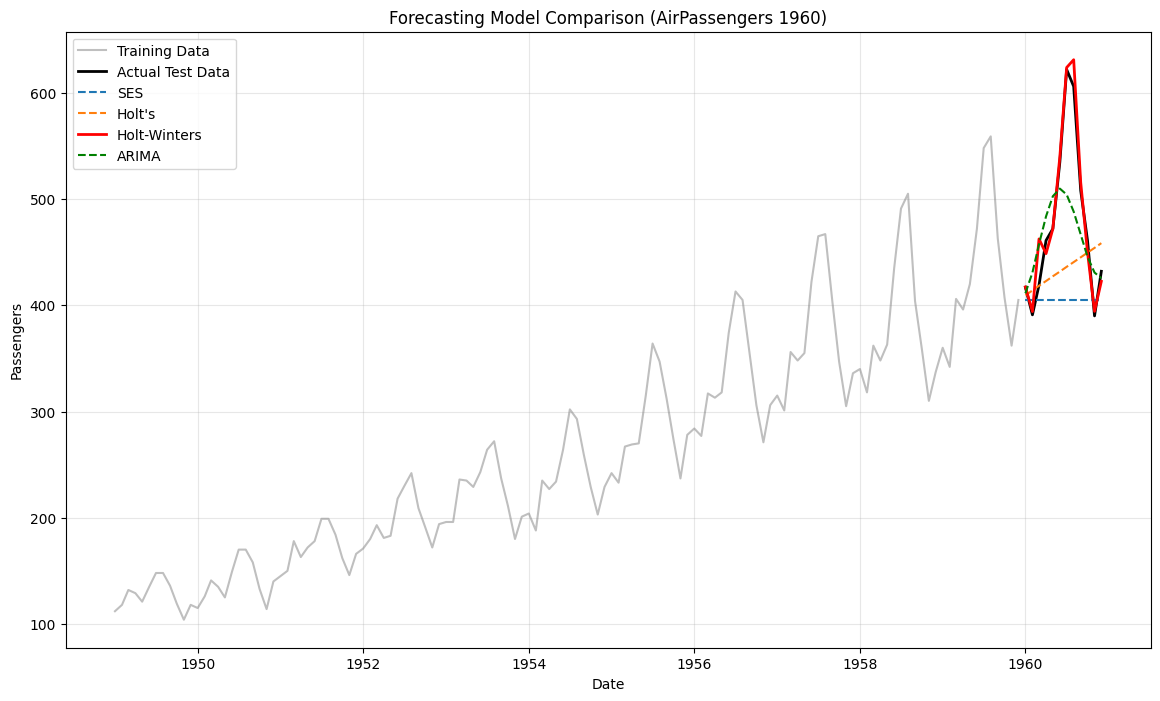

--- Performance Metrics ---
                     RMSE   MAPE (%)
Model                               
Holt-Winters    15.810381   2.207422
ARIMA(2,1,2)    55.222839   8.220491
Holt's Linear   84.384096  11.619686
SES            102.976535  14.251339


In [11]:
# --- 4. Visualization ---
plt.figure(figsize=(14, 8))
plt.plot(train.index, train, label='Training Data', color='gray', alpha=0.5)
plt.plot(test.index, test, label='Actual Test Data', color='black', linewidth=2)

plt.plot(test.index, pred_ses, label='SES', linestyle='--')
plt.plot(test.index, pred_holt, label="Holt's", linestyle='--')
plt.plot(test.index, pred_hw, label='Holt-Winters', linewidth=2, color='red')
plt.plot(test.index, pred_arima, label='ARIMA', linestyle='--', color='green')

plt.title('Forecasting Model Comparison (AirPassengers 1960)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("--- Performance Metrics ---")
print(results_df.sort_values(by='MAPE (%)'))